# Capstone Bonus Questions

This notebook contains additional exploratory and analytical questions completed for the week 8 Pyhton Capstone Project

In [14]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# load files
customers = pd.read_csv("customer_list.csv", sep="|")

products = pd.read_csv("Products.csv")

pcategories = pd.read_csv("ProductCategories.csv")

storesales = pd.read_csv("StoreSales.csv")

stored = pd.read_csv("StoreDetail.csv")

In [17]:
# Convert dates
storesales['Transaction Date'] = pd.to_datetime(
    storesales['Transaction Date'])

In [18]:
# Create merged dataframes
sales_store  = pd.merge(
    storesales,
    stored,
    on = 'Store ID',
    how = 'left')

In [19]:
# Sales_products merge 
sales_products = pd.merge(
    sales_store,
    products,
    on='Prod Num',
    how='left'
)

sales_products = pd.merge(
    sales_products,
    pcategories,
    on=['CategoryID', 'SubcategoryID'],
    how='left'
)

## Filtering, Sorting & Exploration

### Question 1
Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [43]:

# January 2024 transactions
jan_2024 = storesales[
    (storesales['Transaction Date'].dt.month == 1) &
    (storesales['Transaction Date'].dt.year == 2024)
]

# Transactions over $500
high_transactions = (
    jan_2024[jan_2024['Sale Amount'] > 500]
    .sort_values(by='Sale Amount', ascending=False)
)

high_transactions.head(20)


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
138720,2024-01-27,701,NaN,105341-IT,1763.7
138780,2024-01-27,736,NaN,105341-IT,1763.7
133164,2024-01-01,726,NaN,105341-IT,1763.7
134987,2024-01-09,731,NaN,105341-IT,1763.7
135291,2024-01-10,823,337.0,105341-IT,1763.7
136870,2024-01-18,736,NaN,105341-IT,1763.7
135133,2024-01-09,872,NaN,105341-IT,1763.7
139709,2024-01-31,822,NaN,105341-IT,1763.7
136672,2024-01-17,736,NaN,105326-IT,1717.7
138658,2024-01-26,836,NaN,105326-IT,1717.7


### Question 2
Find all products whose product number begins with 10525. What category and subcategory do they
belong to?

In [24]:

products_10525 = products[
    products['Prod Num'].str.startswith('10525')
]

products_10525 = pd.merge(
    products_10525,
    pcategories,
    on=['CategoryID', 'SubcategoryID'],
    how='left'
)

products_10525

,Prod Num,Product,CategoryID,SubcategoryID,Category,Subcategory
0,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,Tablets
1,105251-IT,Lenovo Tab P12 Pro,120,120-tab,Technology & Accessories,Tablets
2,105252-IT,Microsoft Surface Pro 9,120,120-tab,Technology & Accessories,Tablets
3,105253-IT,"Apple iPad Pro (12.9-inch, M2)",120,120-tab,Technology & Accessories,Tablets
4,105254-IT,Chuwi HiPad Max,120,120-tab,Technology & Accessories,Tablets
5,105255-IT,Lenovo Yoga Smart Tab,120,120-tab,Technology & Accessories,Tablets
6,105256-IT,ASUS Vivobook 13 Slate OLED,120,120-tab,Technology & Accessories,Tablets
7,105257-IT,Samsung Galaxy Tab S9 Ultra,120,120-tab,Technology & Accessories,Tablets
8,105258-IT,Apple iPad Air (10.9-inch),120,120-tab,Technology & Accessories,Tablets
9,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,Tablets


### Question 3
Which stores in your assigned territories had at least one transaction with a sale amount over
$1,000? How many such transactions did each store have?

In [25]:
high_sales = sales_store[
    (sales_store['State'].isin(['Maine', 'Massachusetts'])) &
    (sales_store['Sale Amount'] > 1000)
]

store_high_sales = (
    high_sales
    .groupby(['Store Location', 'State'])
    .size()
    .reset_index(name='Transaction Count')
    .sort_values(by='Transaction Count', ascending=False)
)

store_high_sales

,Store Location,State,Transaction Count
23,Worcester,Massachusetts,163
10,Leominster,Massachusetts,107
14,Nantucket,Massachusetts,98
22,South Portland,Maine,97
21,Somerville,Massachusetts,96
8,Holyoke,Massachusetts,95
19,Provincetown,Massachusetts,94
9,Kennebunkport,Maine,93
1,Bangor,Maine,93
16,Northampton,Massachusetts,91


## Aggregation & NumPy

### Question 4
What is the total sales revenue across all in-store transactions in the dataset? What is the average
transaction amount? What is the standard deviation?

In [46]:
total_revenue = storesales['Sale Amount'].sum()

average_transaction = storesales['Sale Amount'].mean()

std_deviation = storesales['Sale Amount'].std()

print("Total Revenue:", total_revenue)
print("Average Transaction:", average_transaction)
print("Standard Deviation:", std_deviation)

Total Revenue: 45370048.85
Average Transaction: 135.3808499115266
Standard Deviation: 279.7167248966467


### Question 6
What is the total revenue for each product category across all territories, sorted from highest to
lowest? Which category has the most individual transactions?

In [27]:
category_revenue = (
    sales_products
    .groupby('Category')['Sale Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Technology & Accessories    31891406.58
Textbooks                    7961357.21
Apparel and Merchandise      2043382.60
Art Supplies                 1938358.84
Books (General)              1070718.51
Stationery and Supplies       702088.52
Name: Sale Amount, dtype: float64

In [30]:
## Transactions by category
category_transactions = (
    sales_products
    .groupby('Category')
    .size()
    .sort_values(ascending=False)
)

category_transactions

Category
Stationery and Supplies     69176
Technology & Accessories    68344
Apparel and Merchandise     63346
Art Supplies                62028
Textbooks                   45924
Books (General)             35196
dtype: int64

# Merging & Grouping

### Question 9:
What is total revenue by region across the full dataset? Which region generates the most revenue?
(Requires merging with StoreDetail and grouping by Region.)


In [31]:
region_revenue = (
    sales_store
    .groupby('Region')['Sale Amount']
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
Northeast    24237526.98
South         7996850.12
East          6723039.53
West          6412632.22
Name: Sale Amount, dtype: float64

### Question 10 
For each product subcategory in your territories, calculate the total revenue and number of
transactions. Which subcategories are driving the most revenue? (Requires merging StoreSales →
Products → ProductCategories.)

In [34]:

subcategory_analysis = (
    sales_products[
        sales_products['State'].isin(['Maine', 'Massachusetts'])
    ]
    .groupby('Subcategory')
    .agg({
        'Sale Amount':'sum',
        'Prod Num':'count'
    })
    .rename(columns={'Prod Num':'Transaction Count'})
    .sort_values(by='Sale Amount', ascending=False)
)

subcategory_analysis

,Sale Amount,Transaction Count
Subcategory,,
Laptops,2882742.92,2181
Tablets,1356598.75,1797
Software Download,578625.52,1970
Business & Economics,231118.26,1424
Calculators,211425.70,619
Headphones,206185.11,1772
Health Sciences,182848.94,1022
Social Sciences,165022.25,705
Engineering & Technology,163560.00,1077


In [35]:
sales_store['Year'] = sales_store['Transaction Date'].dt.year
sales_store['Month'] = sales_store['Transaction Date'].dt.to_period('M')

# Advanced / Stretch

### Question 13
Compare year-over-year revenue for your territories. Is each territory trending up or down between years?

In [38]:

yoy_revenue = (sales_store[sales_store['State'].isin(['Maine', 'Massachusetts'])]
    .groupby(['State', 'Year'])['Sale Amount']
    .sum()
    .reset_index()
)

yoy_revenue

,State,Year,Sale Amount
0,Maine,2022,279074.94
1,Maine,2023,450814.79
2,Maine,2024,452377.73
3,Maine,2025,694982.29
4,Massachusetts,2022,863610.11
5,Massachusetts,2023,1366498.43
6,Massachusetts,2024,1371483.59
7,Massachusetts,2025,2131664.14


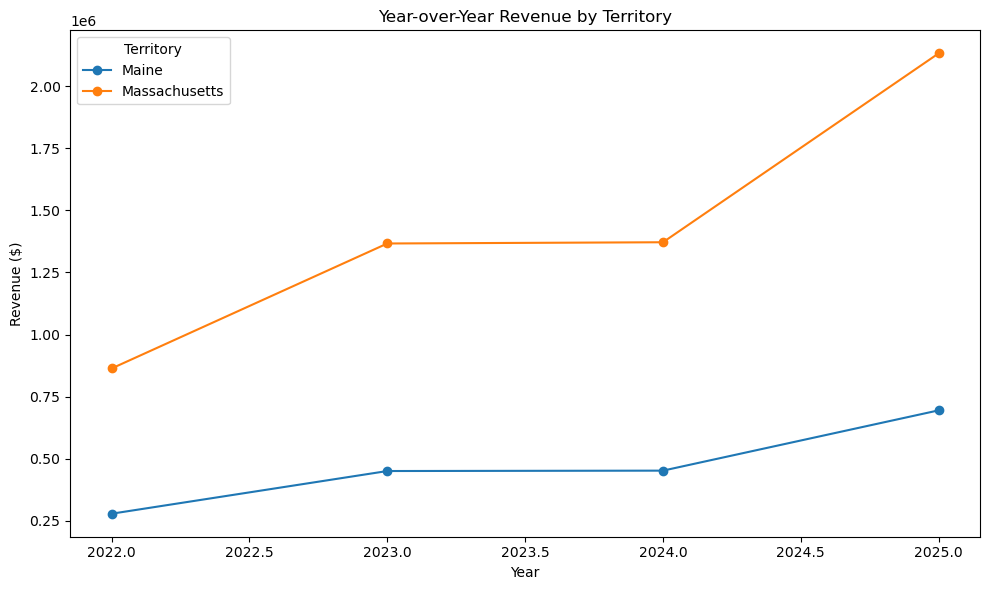

In [39]:
# OPTIONAL CHART:
yoy_pivot = yoy_revenue.pivot(
    index='Year',
    columns='State',
    values='Sale Amount'
)

yoy_pivot.plot(kind='line', marker='o', figsize=(10,6))

plt.title('Year-over-Year Revenue by Territory')
plt.xlabel('Year')
plt.ylabel('Revenue ($)')
plt.legend(title='Territory')
plt.tight_layout()
plt.show()

### Question 14
Identify the single best month and single worst month for each of your territories over the full data period.

In [40]:

monthly_revenue = (
    sales_store[sales_store['State'].isin(['Maine', 'Massachusetts'])]
    .groupby(['State', 'Month'])['Sale Amount']
    .sum()
    .reset_index()
)

best_months = monthly_revenue.loc[
    monthly_revenue.groupby('State')['Sale Amount'].idxmax()
]

worst_months = monthly_revenue.loc[
    monthly_revenue.groupby('State')['Sale Amount'].idxmin()
]

best_and_worst_months = pd.concat(
    [best_months.assign(Result='Best Month'),
     worst_months.assign(Result='Worst Month')]
)

best_and_worst_months

,State,Month,Sale Amount,Result
45,Maine,2025-10,93456.68,Best Month
93,Massachusetts,2025-10,277382.19,Best Month
0,Maine,2022-01,15700.31,Worst Month
56,Massachusetts,2022-09,58716.74,Worst Month


### Question 15:
Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line
alongside the monthly revenue chart. Is your territory trending up or down overall?

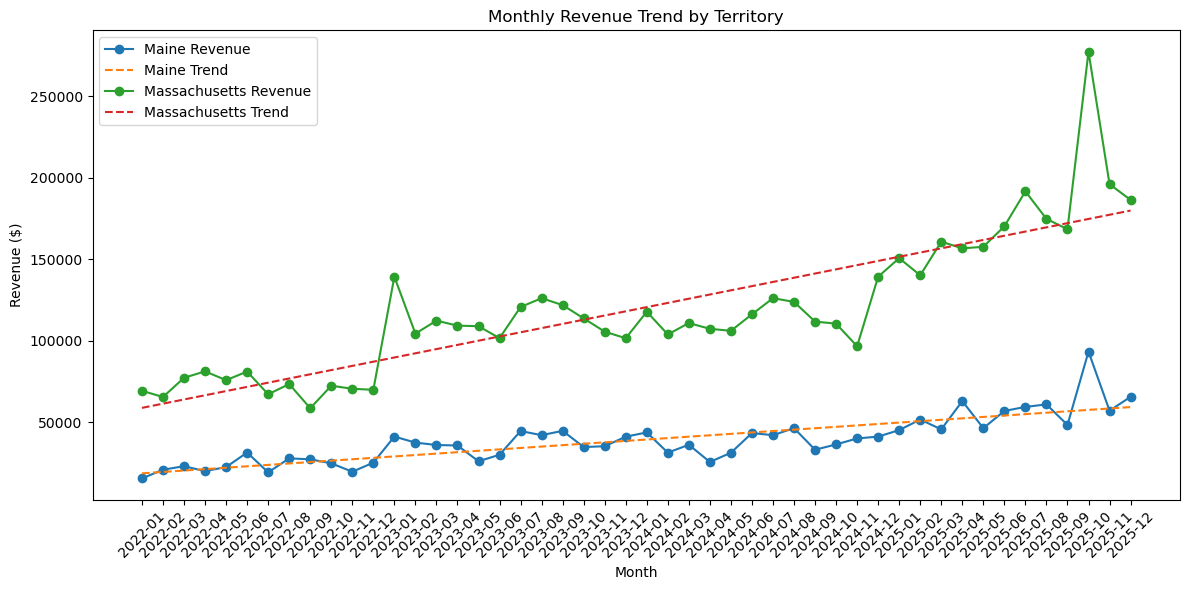

In [41]:

from sklearn.linear_model import LinearRegression

trend_data = monthly_revenue.copy()
trend_data['Month_Number'] = trend_data.groupby('State').cumcount() + 1

plt.figure(figsize=(12,6))

for state in trend_data['State'].unique():
    state_data = trend_data[trend_data['State'] == state].copy()

    X = state_data[['Month_Number']]
    y = state_data['Sale Amount']

    model = LinearRegression()
    model.fit(X, y)

    state_data['Trend'] = model.predict(X)

    plt.plot(state_data['Month'].astype(str), y, marker='o', label=f'{state} Revenue')
    plt.plot(state_data['Month'].astype(str), state_data['Trend'], linestyle='--', label=f'{state} Trend')

plt.title('Monthly Revenue Trend by Territory')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()